# 03 — MLP Surrogate
**Model:** Multi-Layer Perceptron (Neural Network) — numpy only, no torch/tensorflow.

**Why MLP here:**
MLP can fit non-linear, non-monotonic trends (important given the non-trivial
C11/C12 variation you see at mid-Cr compositions). With only 17 points it is
prone to overfitting, so we use strong regularisation (L2 weight decay) and LOO-CV.

**Architecture:**
```
Input(1) → Dense(16, tanh) → Dense(16, tanh) → Dense(1, linear)
```
Small on purpose — more neurons would overfit badly at N=17.

**Training:** Mini-batch gradient descent with Adam optimiser (numpy implementation).

**Limitation:** No native uncertainty output. Bootstrap ensemble used to get
approximate prediction intervals.

**Outputs saved to** `../analysis/`:
- `mlp_predictions.png`
- `mlp_loo_residuals.png`
- `mlp_results.pkl`


---
## Cell 1 — Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle, sys, os
import warnings; warnings.filterwarnings('ignore')
plt.rcParams.update({'font.size': 12, 'figure.dpi': 120})

sys.path.insert(0, os.path.dirname(os.path.abspath('data_utils.py')))

from data_utils import (load_data, plot_loo_residuals,
                        LeaveOneOut, mean_absolute_error, r2_score,
                        TARGETS, PALETTE)

# print('Imports OK — numpy-only MLP, no torch/tensorflow, no sklearn')

/home/sayeed/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


---
## Cell 2 — Load Data

In [2]:
DATA_PATHS = {
    'raw':       '../analysis/elastic_constants_fecr_raw.csv',
    'corrected': '../analysis/elastic_constants_fecr_corrected.csv',
}

results = {}

for mode, path in DATA_PATHS.items():
    d = load_data(path)
    df           = d['df']
    tier = np.where(df['n_cr'] <= 9,  'A',
           np.where(df['n_cr'] <= 13, 'B', 'C'))
    results[mode] = dict(
        df             = df,
        X              = d['X'],
        X_pred         = d['X_pred'],
        x_pred_atoms   = d['x_pred_atoms'],
        targets        = d['targets'],
        alpha          = d['alpha'],
        noise_gpa      = d['noise_gpa'],
        flagged        = d['flagged'],
        afm_init       = d['afm_init'],
        vcr_geometry   = d['vcr_geometry'],
        cubic_enforced = d['cubic_enforced'],
        tier           = tier,
        mlp_models     = {},
        mlp_results    = {},
    )

print('\nBoth datasets loaded.')
for mode in DATA_PATHS:
    r = results[mode]
    print(f"  {mode:10s}: {len(r['df'])} tags | "
          f"noise range C11: {r['alpha']['C11'].min():.2f}–"
          f"{r['alpha']['C11'].max():.2f} GPa²")


Loaded 17 tags — mode: RAW
tag            n_cr  σ C11+2C12  σ C11-C12   σ C44   afm  vcr_geo  cub_enf
--------------------------------------------------------------------
fe16cr00          0       1.000      1.000   1.000 False    False    False
fe15cr01          1       1.000      1.000   1.000 False    False    False
fe14cr02          2       1.000      1.000   1.000 False    False    False
fe13cr03          3       1.000      1.000   1.000 False    False    False
fe12cr04          4       1.000      1.000   1.000 False    False    False
fe11cr05          5       1.000      1.000   1.000 False    False    False
fe10cr06          6       1.000      1.000   1.000 False    False    False
fe09cr07          7       1.000      1.000   1.000 False    False    False
fe08cr08          8       1.000      1.000   1.000 False    False    False
fe07cr09          9       1.000      1.000   1.000 False    False    False
fe06cr10         10       1.000      1.000   1.000 False    False    False
fe0

---
## Cell 3 — MLP Implementation (numpy)

### What each component does:

**Weights and biases:** Randomly initialised (He init — scaled by √(2/n_in)).
Why He? Prevents vanishing/exploding activations in tanh networks at init time.

**Forward pass:** Input → linear transform + bias → tanh activation → repeat → output.

**Loss:** Weighted MSE + L2 regularisation on all weights.
```
L = Σ w_i·(y_i − ŷ_i)² + λ·Σ ||W||²
```

**Backward pass:** Chain rule through each layer (backpropagation).

**Adam optimiser:** Adaptive per-parameter learning rates using first and second
moment estimates. More robust than plain SGD for small noisy datasets.
```
m = β₁·m + (1−β₁)·g        # first moment (mean of gradients)
v = β₂·v + (1−β₂)·g²       # second moment (variance of gradients)
θ = θ − α · m̂ / (√v̂ + ε)  # parameter update
```

In [3]:
class MLP:
    """
    Two-hidden-layer MLP for scalar regression.
    Architecture: 1 → h1 → h2 → 1  (tanh activations, linear output)
    Trained with Adam + L2 weight decay + sample weights.

    Parameters
    ----------
    hidden  : tuple  — neurons per hidden layer, e.g. (16, 16)
    lr      : float  — Adam learning rate
    n_epochs: int    — training epochs
    lam     : float  — L2 weight decay
    seed    : int
    """
    def __init__(self, hidden=(16,16), lr=1e-2, n_epochs=3000, lam=1e-3, seed=42):
        self.hidden   = hidden
        self.lr       = lr
        self.n_epochs = n_epochs
        self.lam      = lam
        self.seed     = seed
        self.loss_history = []

    def _init_params(self, layer_sizes):
        """He initialisation for all weight matrices."""
        rng = np.random.default_rng(self.seed)
        self.W, self.b = [], []
        for n_in, n_out in zip(layer_sizes[:-1], layer_sizes[1:]):
            self.W.append(rng.normal(0, np.sqrt(2./n_in), (n_in, n_out)))
            self.b.append(np.zeros(n_out))

    def _forward(self, X):
        """Forward pass. Returns activations at each layer."""
        A = [X]          # A[0] = input
        for i, (W, b) in enumerate(zip(self.W, self.b)):
            Z = A[-1] @ W + b
            if i < len(self.W) - 1:  # hidden layers
                A.append(np.tanh(Z))
            else:                     # output layer: linear
                A.append(Z)
        return A

    def _backward(self, A, y, sw):
        """
        Backpropagation.
        Returns list of (dW, db) gradients, one per layer.
        sw: sample weights (n,)
        """
        n   = len(y)
        dWs, dbs = [], []
        # Output layer delta: weighted MSE gradient
        pred = A[-1].flatten()
        delta = -2 * sw * (y - pred) / n    # (n,)
        delta = delta.reshape(-1, 1)
        for i in reversed(range(len(self.W))):
            dW = A[i].T @ delta + self.lam * self.W[i]
            db = delta.sum(axis=0)
            dWs.insert(0, dW)
            dbs.insert(0, db)
            if i > 0:   # backprop through tanh
                delta = (delta @ self.W[i].T) * (1 - A[i]**2)
        return dWs, dbs

    def fit(self, X, y, sample_weight=None):
        """Train MLP with Adam optimiser."""
        if sample_weight is None:
            sample_weight = np.ones(len(y))
        sw = sample_weight / sample_weight.sum() * len(y)

        # Normalise inputs and targets for stable training
        self.X_mean, self.X_std = X.mean(), X.std() + 1e-8
        self.y_mean, self.y_std = y.mean(), y.std() + 1e-8
        Xn = (X - self.X_mean) / self.X_std
        yn = (y - self.y_mean) / self.y_std

        sizes = [1] + list(self.hidden) + [1]
        self._init_params(sizes)

        # Adam state
        m = [np.zeros_like(W) for W in self.W]
        v = [np.zeros_like(W) for W in self.W]
        mb = [np.zeros_like(b) for b in self.b]
        vb = [np.zeros_like(b) for b in self.b]
        beta1, beta2, eps_adam = 0.9, 0.999, 1e-8

        self.loss_history = []
        for epoch in range(1, self.n_epochs + 1):
            A    = self._forward(Xn)
            pred = A[-1].flatten()
            loss = np.sum(sw * (yn - pred)**2) / len(yn) + \
                   self.lam * sum(np.sum(W**2) for W in self.W)
            self.loss_history.append(loss)
            dWs, dbs = self._backward(A, yn, sw)
            for i in range(len(self.W)):
                m[i]  = beta1*m[i]  + (1-beta1)*dWs[i]
                v[i]  = beta2*v[i]  + (1-beta2)*dWs[i]**2
                mb[i] = beta1*mb[i] + (1-beta1)*dbs[i]
                vb[i] = beta2*vb[i] + (1-beta2)*dbs[i]**2
                mc = m[i]  / (1 - beta1**epoch)
                vc = v[i]  / (1 - beta2**epoch)
                mbc= mb[i] / (1 - beta1**epoch)
                vbc= vb[i] / (1 - beta2**epoch)
                self.W[i] -= self.lr * mc  / (np.sqrt(vc)  + eps_adam)
                self.b[i] -= self.lr * mbc / (np.sqrt(vbc) + eps_adam)
        return self

    def predict(self, X):
        Xn = (X - self.X_mean) / self.X_std
        A  = self._forward(Xn)
        return A[-1].flatten() * self.y_std + self.y_mean

print('MLP class defined')

MLP class defined


---
## Cell 4 — Bootstrap Uncertainty

Since MLP has no analytic uncertainty, we use **bootstrap ensembling**:
train N_BOOT models on random samples-with-replacement of the data,
then use their prediction spread as an approximate confidence interval.

With N=17, bootstrap std is a rough estimate — treat it as indicative, not calibrated.

In [4]:
def bootstrap_predict(X_tr, y_tr, sw, X_pred, n_boot=50,
                       hidden=(16,16), lr=1e-2, n_epochs=3000, lam=1e-3, seed=0):
    """
    Returns mean and std of N_BOOT bootstrapped MLP predictions at X_pred.
    Each bootstrap model trains on a resample-with-replacement of the data.
    """
    rng  = np.random.default_rng(seed)
    preds = []
    n = len(X_tr)
    for b in range(n_boot):
        idx = rng.integers(0, n, size=n)
        Xb, yb, wb = X_tr[idx], y_tr[idx], sw[idx]
        m = MLP(hidden=hidden, lr=lr, n_epochs=n_epochs, lam=lam, seed=seed+b)
        m.fit(Xb, yb, sample_weight=wb)
        preds.append(m.predict(X_pred))
    preds = np.array(preds)   # (n_boot, n_pred)
    return preds.mean(axis=0), preds.std(axis=0)

print('Bootstrap function defined')

Bootstrap function defined


---
## Cell 5 — Hyperparameter Search + LOO-CV

In [5]:
HIDDEN_OPTS = [(8, 8), (16, 16)]
LR_OPTS     = [5e-3, 1e-2]
LAM_OPTS    = [1e-3, 1e-2]
N_EPOCHS    = 3000


def mlp_loo(X, y, sw, hidden, lr, lam, n_epochs):
    loo = LeaveOneOut()
    preds, trues = [], []
    for tr, te in loo.split(X):
        m = MLP(hidden=hidden, lr=lr, n_epochs=n_epochs, lam=lam)
        m.fit(X[tr], y[tr], sample_weight=sw[tr])
        preds.append(float(m.predict(X[te])))
        trues.append(float(y[te[0]]))
    preds  = np.array(preds)
    trues  = np.array(trues)
    return (mean_absolute_error(trues, preds),
            r2_score(trues, preds),
            preds, trues)


for mode in DATA_PATHS:
    r = results[mode]
    print(f'\n{"═"*55}')
    print(f'  Dataset: {mode.upper()}')
    print(f'{"═"*55}')
    best_params = {}

    for tname in TARGETS:
        y = r['targets'][tname]
        # Per-constant sample weights
        noise = r['noise_gpa'][tname]
        w = 1.0 / (noise ** 2)
        w = w / w.sum() * len(w)

        print(f'\n  ── {tname} ──────────────────────────')
        best_mae = np.inf
        for hid in HIDDEN_OPTS:
            for lr in LR_OPTS:
                for lam in LAM_OPTS:
                    mae, r2, _, _ = mlp_loo(
                        r['X'], y, w, hid, lr, lam, N_EPOCHS)
                    print(f'    h={str(hid):8s} lr={lr:.0e} '
                          f'λ={lam:.0e}  '
                          f'MAE={mae:.2f} GPa  R²={r2:.4f}')
                    if mae < best_mae:
                        best_mae = mae
                        best_params[tname] = {
                            'hidden': hid, 'lr': lr, 'lam': lam}
        print(f'    → Best: {best_params[tname]}  '
              f'(MAE={best_mae:.2f})')

    r['best_params'] = best_params


═══════════════════════════════════════════════════════
  Dataset: RAW
═══════════════════════════════════════════════════════

  ── C11 ──────────────────────────
    h=(8, 8)   lr=5e-03 λ=1e-03  MAE=23.62 GPa  R²=0.8916
    h=(8, 8)   lr=5e-03 λ=1e-02  MAE=20.22 GPa  R²=0.9141
    h=(8, 8)   lr=1e-02 λ=1e-03  MAE=24.33 GPa  R²=0.8853
    h=(8, 8)   lr=1e-02 λ=1e-02  MAE=19.24 GPa  R²=0.9191
    h=(16, 16) lr=5e-03 λ=1e-03  MAE=24.00 GPa  R²=0.8908
    h=(16, 16) lr=5e-03 λ=1e-02  MAE=19.31 GPa  R²=0.9189
    h=(16, 16) lr=1e-02 λ=1e-03  MAE=25.40 GPa  R²=0.8777
    h=(16, 16) lr=1e-02 λ=1e-02  MAE=19.71 GPa  R²=0.9176
    → Best: {'hidden': (8, 8), 'lr': 0.01, 'lam': 0.01}  (MAE=19.24)

  ── C12 ──────────────────────────
    h=(8, 8)   lr=5e-03 λ=1e-03  MAE=24.20 GPa  R²=0.4293
    h=(8, 8)   lr=5e-03 λ=1e-02  MAE=15.59 GPa  R²=0.7013
    h=(8, 8)   lr=1e-02 λ=1e-03  MAE=24.52 GPa  R²=0.4220
    h=(8, 8)   lr=1e-02 λ=1e-02  MAE=15.79 GPa  R²=0.6976
    h=(16, 16) lr=5e-03 λ=1e-03  

---
## Cell 6 — Train Final Models + Bootstrap Uncertainty

In [6]:
N_BOOT = 50

for mode in DATA_PATHS:
    r = results[mode]
    print(f'\n[{mode}]')
    for tname in TARGETS:
        y = r['targets'][tname]
        noise = r['noise_gpa'][tname]
        w = 1.0 / (noise ** 2)
        w = w / w.sum() * len(w)

        p = r['best_params'][tname]

        # Final single model
        model = MLP(hidden=p['hidden'], lr=p['lr'],
                    n_epochs=N_EPOCHS, lam=p['lam'])
        model.fit(r['X'], y, sample_weight=w)
        r['mlp_models'][tname] = model

        # Bootstrap uncertainty
        print(f'  {tname}: bootstrap (n={N_BOOT})...')
        mu, sig = bootstrap_predict(
            r['X'], y, w, r['X_pred'],
            n_boot=N_BOOT,
            hidden=p['hidden'], lr=p['lr'],
            n_epochs=N_EPOCHS, lam=p['lam'])

        # LOO-CV
        mae, r2, loo_preds, loo_true = mlp_loo(
            r['X'], y, w,
            p['hidden'], p['lr'], p['lam'], N_EPOCHS)

        r['mlp_results'][tname] = {
            'mu':           mu,
            'std':          sig,
            'mae':          mae,
            'r2':           r2,
            'loo_true':     loo_true,
            'loo_preds':    loo_preds,
            'residuals':    loo_true - loo_preds,
            'loss_history': model.loss_history,
            'best_params':  p,
        }
        print(f'    LOO MAE={mae:.2f} GPa  R²={r2:.4f}')


[raw]
  C11: bootstrap (n=50)...


    LOO MAE=19.24 GPa  R²=0.9191
  C12: bootstrap (n=50)...
    LOO MAE=15.59 GPa  R²=0.7013
  C44: bootstrap (n=50)...
    LOO MAE=3.26 GPa  R²=0.6965

[corrected]
  C11: bootstrap (n=50)...
    LOO MAE=20.52 GPa  R²=0.9109
  C12: bootstrap (n=50)...
    LOO MAE=15.39 GPa  R²=0.6827
  C44: bootstrap (n=50)...
    LOO MAE=3.65 GPa  R²=0.6839


In [7]:
import pickle

for mode in DATA_PATHS:
    r = results[mode]
    with open(f'../analysis/mlp_models_{mode}.pkl', 'wb') as f:
        pickle.dump(r['mlp_models'], f)
    print(f'Saved ../analysis/mlp_models_{mode}.pkl')

Saved ../analysis/mlp_models_raw.pkl
Saved ../analysis/mlp_models_corrected.pkl


---
## Cell 7 — Training Loss Curves

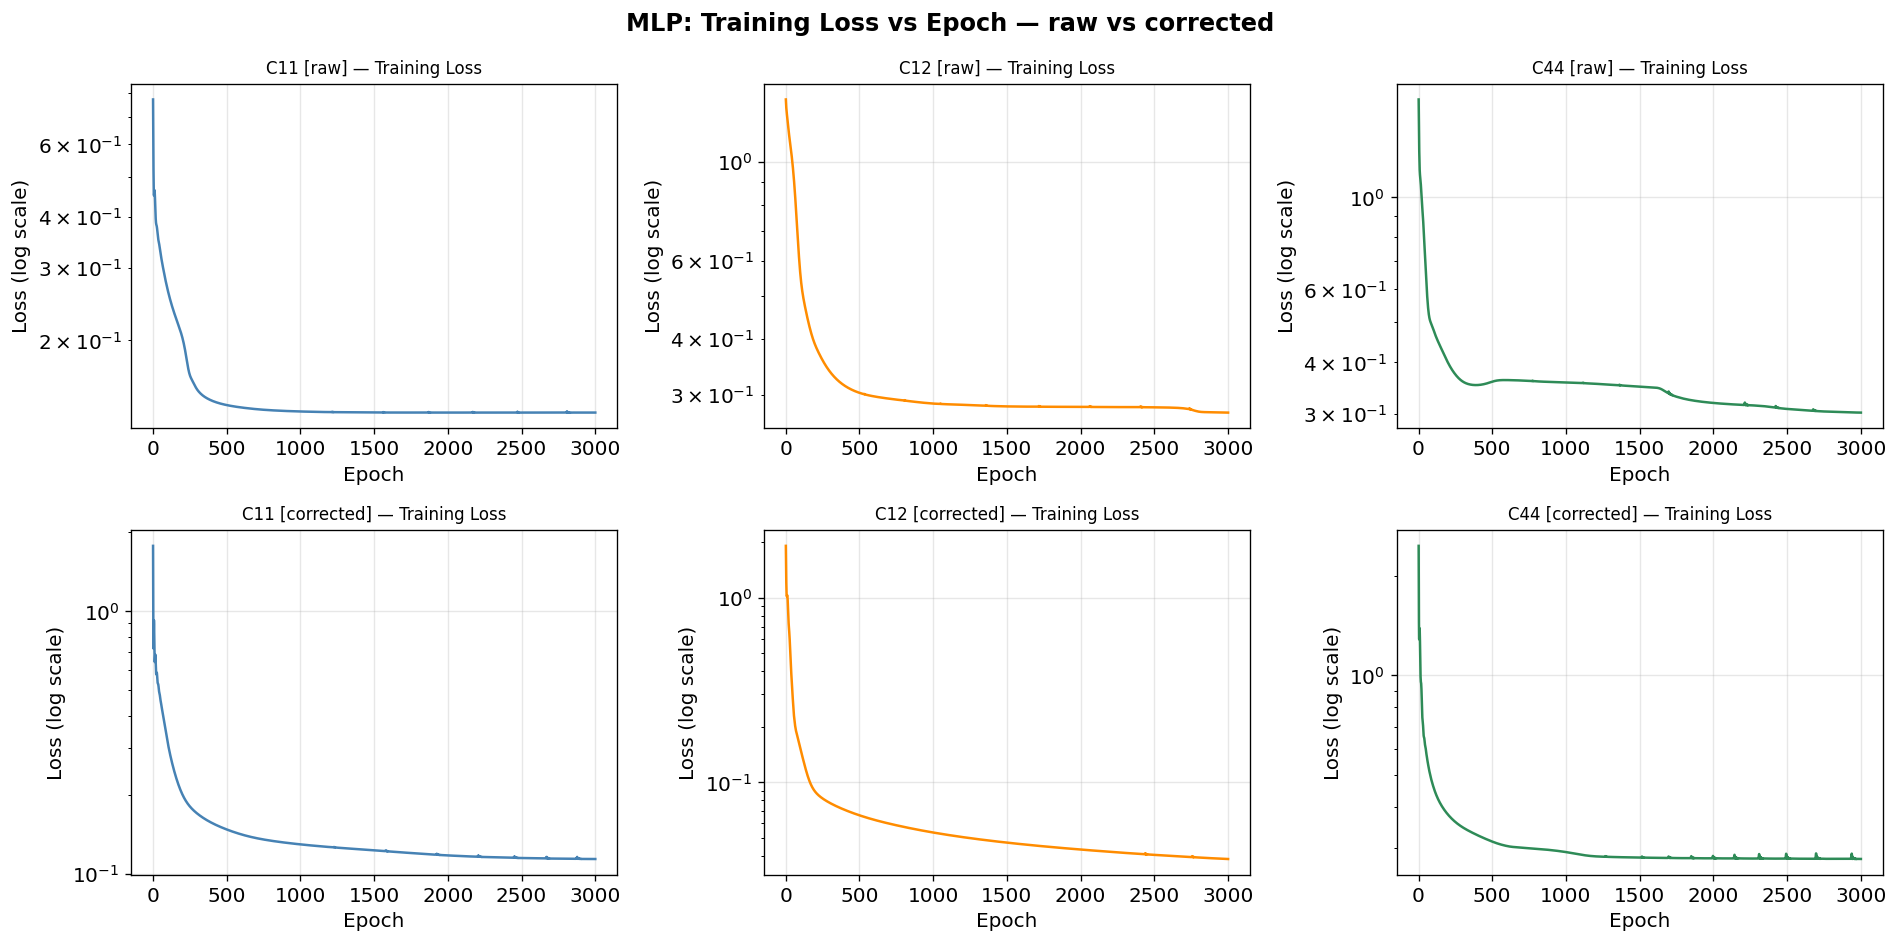

Saved: mlp_training_loss_comparison.png


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for row_idx, mode in enumerate(DATA_PATHS):
    r = results[mode]
    for col_idx, tname in enumerate(TARGETS):
        ax   = axes[row_idx, col_idx]
        loss = r['mlp_results'][tname]['loss_history']
        ax.semilogy(range(1, len(loss)+1), loss,
                    color=PALETTE[tname], lw=1.5)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss (log scale)')
        ax.set_title(f'{tname} [{mode}] — Training Loss', fontsize=10)
        ax.grid(alpha=0.3)

plt.suptitle('MLP: Training Loss vs Epoch — raw vs corrected',
             fontweight='bold')
plt.tight_layout()
plt.savefig('../analysis/mlp_training_loss_comparison.png', bbox_inches='tight')
plt.show()
print('Saved: mlp_training_loss_comparison.png')

---
## Cell 8 — Prediction Plots with Bootstrap Bands

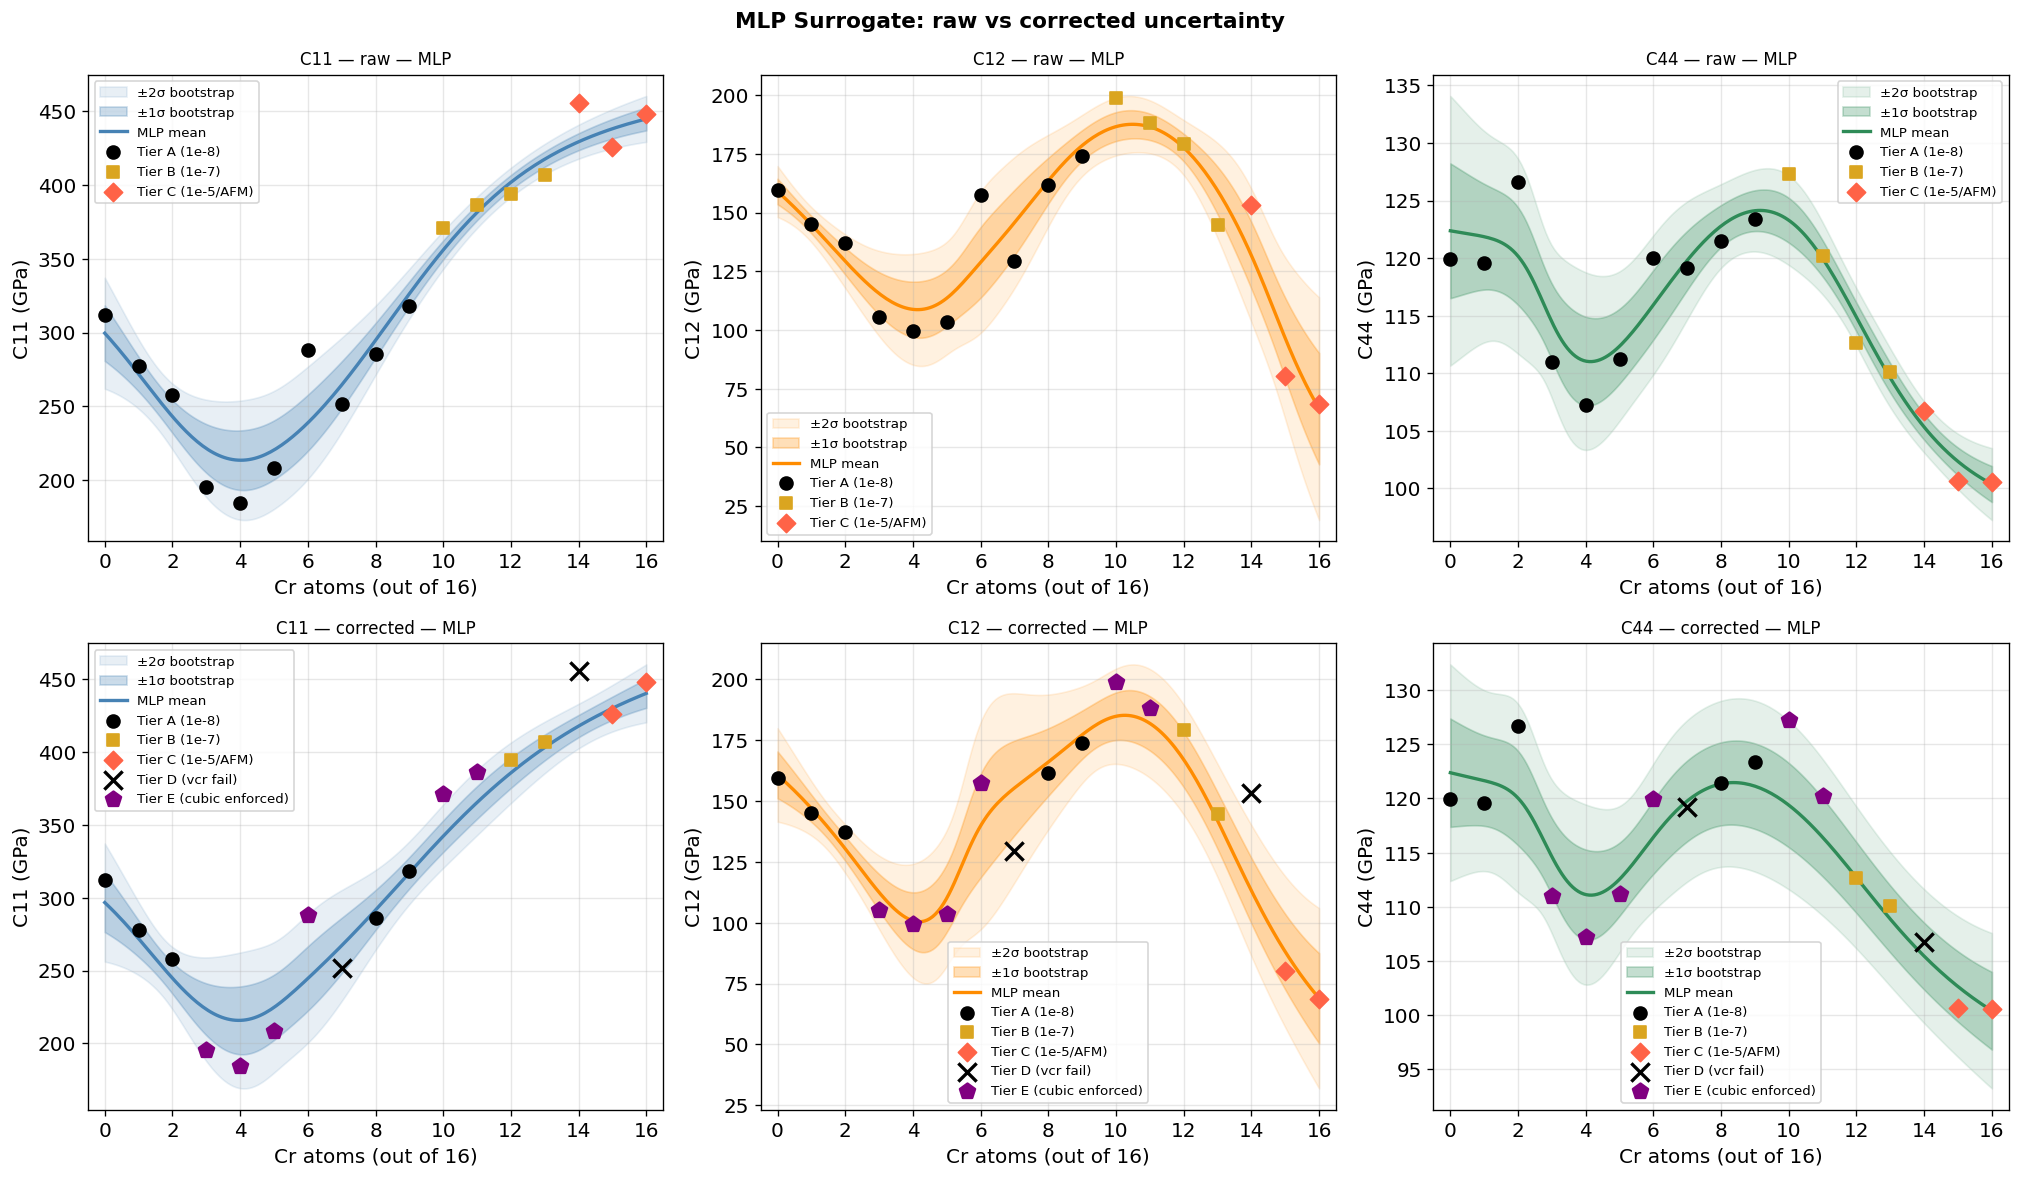

Saved: mlp_predictions_comparison.png


In [9]:
tier_specs = [
    ('A', 'black',     'o', 'Tier A (1e-8)'),
    ('B', 'goldenrod', 's', 'Tier B (1e-7)'),
    ('C', 'tomato',    'D', 'Tier C (1e-5/AFM)'),
]

fig, axes = plt.subplots(2, 3, figsize=(17, 10))

for row_idx, mode in enumerate(DATA_PATHS):
    r = results[mode]
    for col_idx, tname in enumerate(TARGETS):
        ax  = axes[row_idx, col_idx]
        res = r['mlp_results'][tname]
        mu, sig = res['mu'], res['std']
        col = PALETTE[tname]

        ax.fill_between(r['x_pred_atoms'], mu-2*sig, mu+2*sig,
                        alpha=0.12, color=col, label='±2σ bootstrap')
        ax.fill_between(r['x_pred_atoms'], mu-sig,   mu+sig,
                        alpha=0.28, color=col, label='±1σ bootstrap')
        ax.plot(r['x_pred_atoms'], mu, '-', color=col,
                lw=2, label='MLP mean')

        # Tier A/B/C — exclude D and E
        for t_lbl, col_s, mk, lbl in tier_specs:
            m = ((r['tier'] == t_lbl)
                 & ~r['vcr_geometry']
                 & ~r['cubic_enforced'])
            if m.any():
                ax.scatter(r['df']['n_cr'][m],
                           r['targets'][tname][m],
                           color=col_s, s=60, marker=mk,
                           zorder=5, label=lbl)

        # Tier D
        if r['vcr_geometry'].any():
            ax.scatter(r['df']['n_cr'][r['vcr_geometry']],
                       r['targets'][tname][r['vcr_geometry']],
                       color='black', s=120, marker='x',
                       linewidths=2, zorder=6,
                       label='Tier D (vcr fail)')

        # Tier E
        cub = r['cubic_enforced'] & ~r['vcr_geometry']
        if cub.any():
            ax.scatter(r['df']['n_cr'][cub],
                       r['targets'][tname][cub],
                       color='purple', s=90, marker='p',
                       linewidths=1.5, zorder=5,
                       label='Tier E (cubic enforced)')

        ax.set_xlabel('Cr atoms (out of 16)')
        ax.set_ylabel(f'{tname} (GPa)')
        ax.set_title(f'{tname} — {mode} — MLP', fontsize=10)
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)
        ax.set_xlim(-0.5, 16.5)

plt.suptitle('MLP Surrogate: raw vs corrected uncertainty',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../analysis/mlp_predictions_comparison.png', bbox_inches='tight')
plt.show()
print('Saved: mlp_predictions_comparison.png')

---
## Cell 9 — LOO-CV Residuals

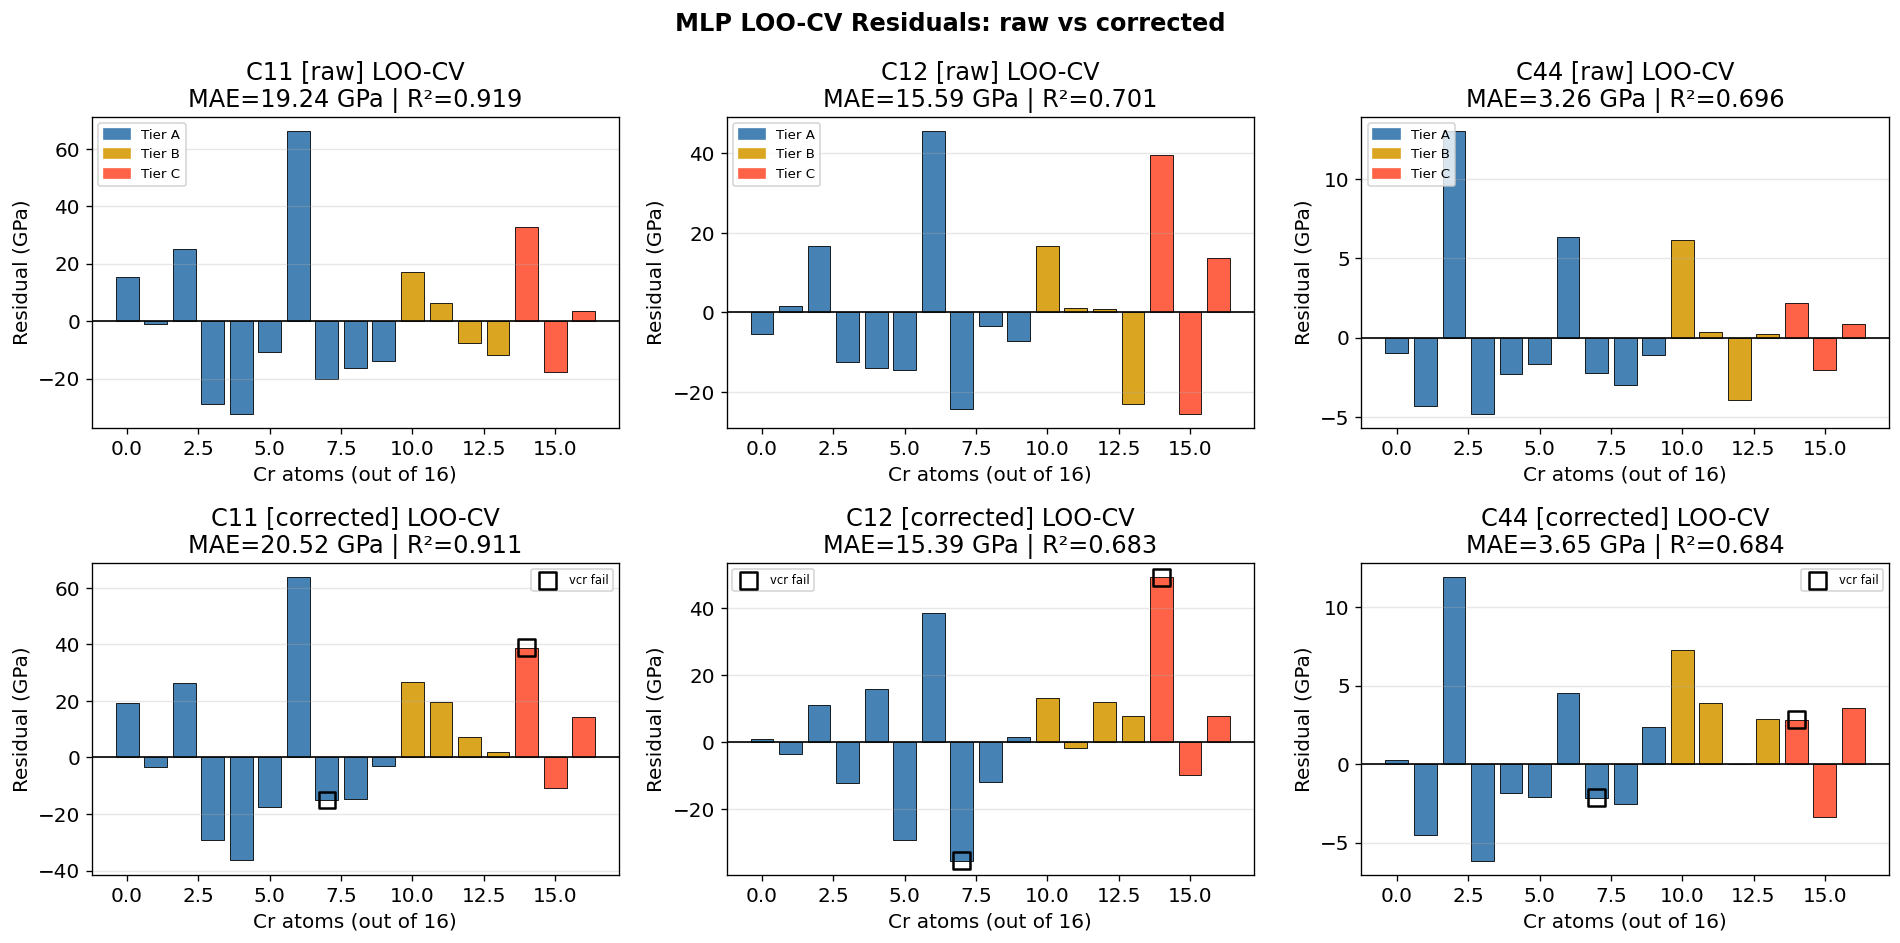

Saved: mlp_loo_residuals_comparison.png


In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for row_idx, mode in enumerate(DATA_PATHS):
    r = results[mode]
    for col_idx, tname in enumerate(TARGETS):
        ax  = axes[row_idx, col_idx]
        res = r['mlp_results'][tname]
        plot_loo_residuals(
            ax,
            res['residuals'],
            r['df']['n_cr'].values,
            r['tier'],
            f"{tname} [{mode}] LOO-CV\n"
            f"MAE={res['mae']:.2f} GPa | R²={res['r2']:.3f}"
        )
        # vcr fail overlay
        if r['vcr_geometry'].any():
            ax.scatter(r['df']['n_cr'][r['vcr_geometry']],
                       res['residuals'][r['vcr_geometry']],
                       marker='s', s=100, facecolors='none',
                       edgecolors='black', linewidths=1.5,
                       zorder=5, label='vcr fail')
            ax.legend(fontsize=7)

plt.suptitle('MLP LOO-CV Residuals: raw vs corrected',
             fontweight='bold')
plt.tight_layout()
plt.savefig('../analysis/mlp_loo_residuals_comparison.png', bbox_inches='tight')
plt.show()
print('Saved: mlp_loo_residuals_comparison.png')

---
## Cell 10 — Export Results

In [11]:
for mode in DATA_PATHS:
    r   = results[mode]
    exp = {}
    for tname in TARGETS:
        res = r['mlp_results'][tname]
        exp[tname] = dict(
            mu           = res['mu'],
            std          = res['std'],
            mae          = res['mae'],
            r2           = res['r2'],
            loo_true     = res['loo_true'],
            loo_preds    = res['loo_preds'],
            residuals    = res['residuals'],
            best_params  = res['best_params'],
        )
    pkl_path = f'../analysis/mlp_results_{mode}.pkl'
    with open(pkl_path, 'wb') as f:
        pickle.dump(exp, f)
    print(f'Saved: mlp_results_{mode}.pkl')

print('\nMLP Summary:')
for mode in DATA_PATHS:
    print(f'\n  [{mode.upper()}]')
    for tname in TARGETS:
        res = results[mode]['mlp_results'][tname]
        p   = res['best_params']
        print(f'    {tname}: h={p["hidden"]}  '
              f'lr={p["lr"]:.0e}  λ={p["lam"]:.0e}  '
              f'MAE={res["mae"]:.2f} GPa  R²={res["r2"]:.4f}')

Saved: mlp_results_raw.pkl
Saved: mlp_results_corrected.pkl

MLP Summary:

  [RAW]
    C11: h=(8, 8)  lr=1e-02  λ=1e-02  MAE=19.24 GPa  R²=0.9191
    C12: h=(8, 8)  lr=5e-03  λ=1e-02  MAE=15.59 GPa  R²=0.7013
    C44: h=(8, 8)  lr=1e-02  λ=1e-02  MAE=3.26 GPa  R²=0.6965

  [CORRECTED]
    C11: h=(16, 16)  lr=1e-02  λ=1e-02  MAE=20.52 GPa  R²=0.9109
    C12: h=(16, 16)  lr=5e-03  λ=1e-03  MAE=15.39 GPa  R²=0.6827
    C44: h=(16, 16)  lr=1e-02  λ=1e-02  MAE=3.65 GPa  R²=0.6839
